# Customer Churn Prediction using Machine Learning

This notebook presents an end-to-end machine learning pipeline for predicting telecom customer churn. The workflow includes data loading, data cleaning, exploratory data analysis (EDA), preprocessing, model training, hyperparameter tuning, feature importance analysis, feature selection, and final model evaluation.

Each section briefly explains the purpose before the corresponding code.

## 6. Train-Test Split

Split the data into training and testing sets to evaluate model performance on unseen data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from google.colab import files

uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (4).csv


## 1. Import Libraries and Load Dataset

Load the required Python libraries and import the telecom churn dataset into a Pandas DataFrame.

In [ ]:
#DATA EXPLORATION
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()
df.shape
df.info()
df.describe
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#TotalCharges and Churn are object/text
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df["TotalCharges"].sample(20)

,TotalCharges
2194,79.5
3276,317.25
577,597.9
1865,4744.35
4147,1901
2478,220.75
1579,950.2
5762,3181.8
6198,630.6
3944,172.35


In [ ]:
#now investigating the suspision
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## 3. Data Cleaning

Handle missing values and prepare the dataset for analysis.

In [ ]:
#since there are 11 rows with empty TotalCharges now we fix them by removing it since 11 is hardly anything out of around 7000 rows
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df.dropna(inplace=True)
df.shape

(7032, 21)

## 2. Initial Data Exploration

Inspect the dataset structure, data types, columns, and identify potential issues such as missing values or incorrect data types.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [ ]:
#NOW THE PART FOR Exploratory Data Analysis (EDA)
df["Churn"].value_counts()


,count
Churn,
No,5163
Yes,1869


In [ ]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

,proportion
Churn,
No,73.42
Yes,26.58


In [ ]:
#but here accuracy is not everything we need other metrics also

The dataset contains 7,032 customers after preprocessing. Approximately 73.4% of customers did not churn, while 26.6% churned. This indicates a moderate class imbalance, which should be considered when evaluating machine learning models. Therefore, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be used alongside Accuracy.

NOW WE TRY TO OBSERVE THE FEATURES THAT INFLUENCE CHURN


First we see the gender. Do male and female customers churn at different rates?

## 4. Exploratory Data Analysis (EDA)

Investigate relationships between individual features and customer churn using summary statistics and cross-tabulations.

In [ ]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


**Observation:** The churn rates for male and female customers are nearly identical. This suggests that gender alone is unlikely to be a significant factor influencing customer churn.

Now we check if senior citizens leave the telecom service more frequently than younger customers?

## 4. Exploratory Data Analysis (EDA)

Investigate relationships between individual features and customer churn using summary statistics and cross-tabulations.

In [ ]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


Senior citizens exhibit a substantially higher churn rate than non-senior citizens, suggesting that age group may be an important predictor of customer churn.

Does having a partner influence customer churn?

## 4. Exploratory Data Analysis (EDA)

Investigate relationships between individual features and customer churn using summary statistics and cross-tabulations.

In [ ]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


INSTEAD OF MANUALLY HAVING TO CHECK ONE BY ONE WE CHECK BY LOOPING

## 4. Exploratory Data Analysis (EDA)

Investigate relationships between individual features and customer churn using summary statistics and cross-tabulations.

In [ ]:
categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

for feature in categorical_features:
    print("="*60)
    print(f"Feature: {feature}\n")

    print(
        pd.crosstab(
            df[feature],
            df["Churn"],
            normalize="index"
        ) * 100
    )

    print("\n")

Feature: gender

Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565


Feature: SeniorCitizen

Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


Feature: Partner

Churn           No        Yes
Partner                      
No       67.023908  32.976092
Yes      80.282935  19.717065


Feature: Dependents

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.468795  15.531205


Feature: PhoneService

Churn                No        Yes
PhoneService                      
No            75.000000  25.000000
Yes           73.252519  26.747481


Feature: MultipleLines

Churn                    No        Yes
MultipleLines                         
No                74.918759  25.081241
No phone service  75.000000  25.000000
Yes               71.351534  28.648466


Feature: Inter

## 4. Exploratory Data Analysis (EDA)

Investigate relationships between individual features and customer churn using summary statistics and cross-tabulations.

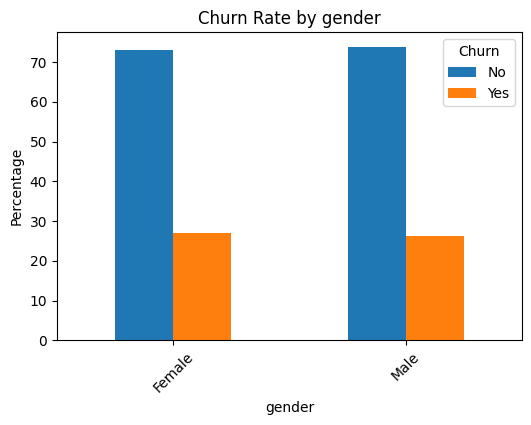

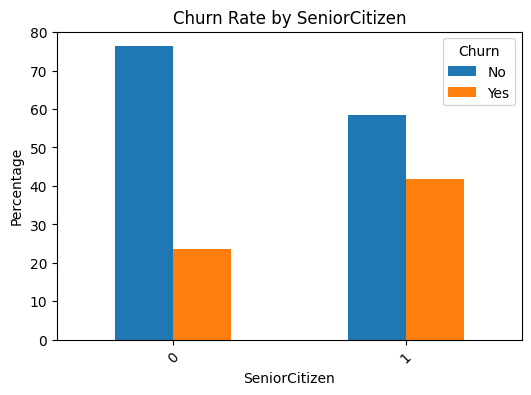

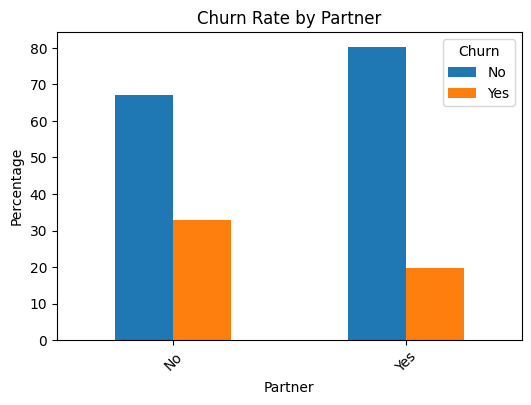

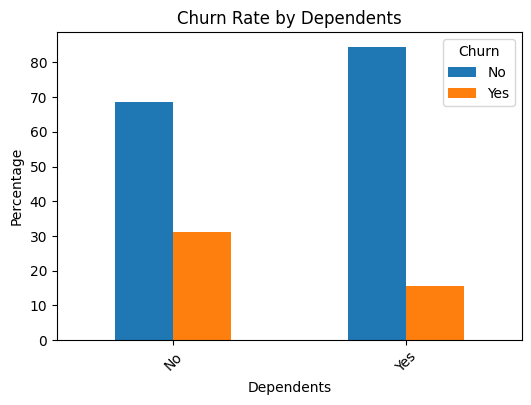

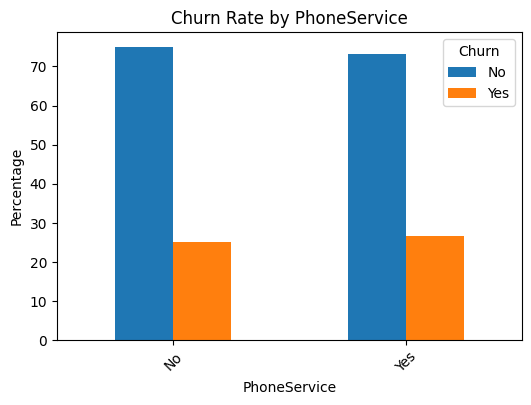

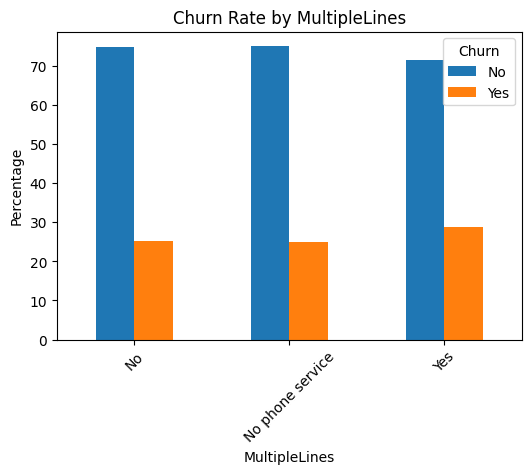

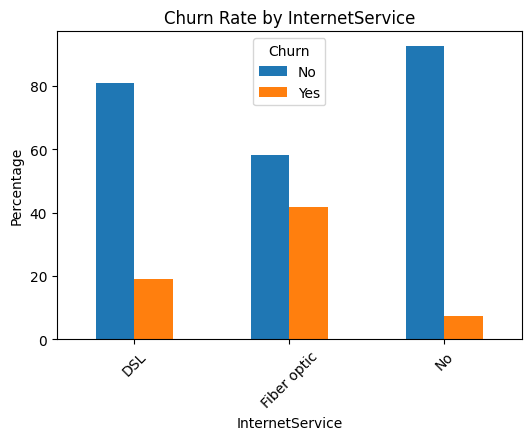

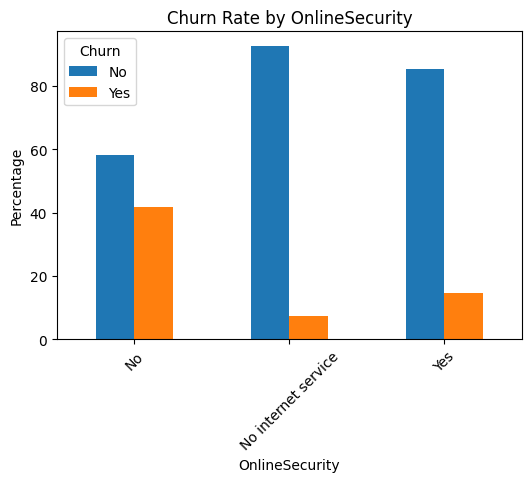

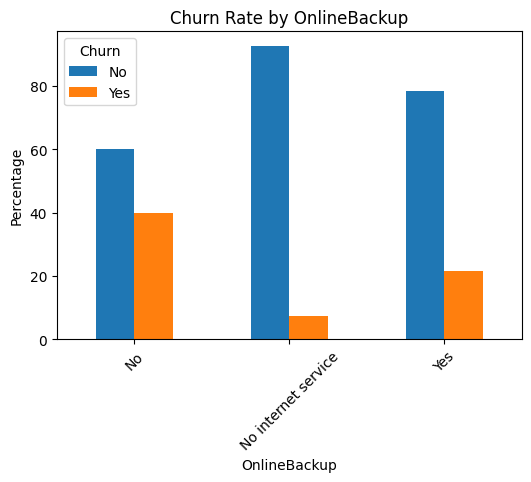

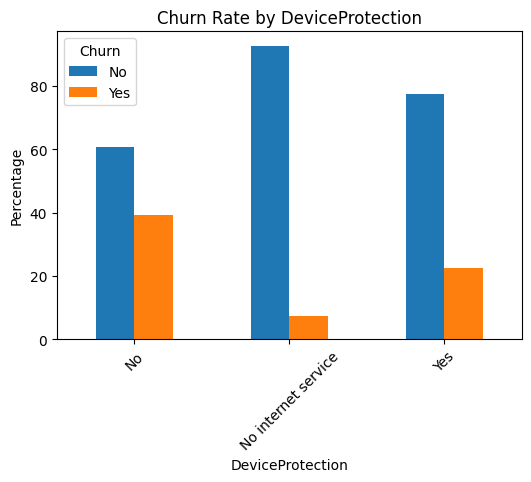

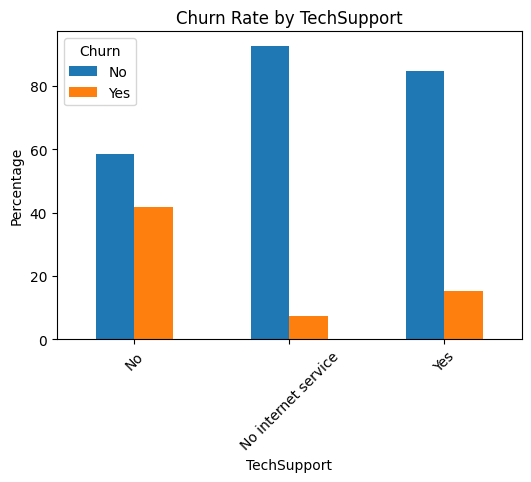

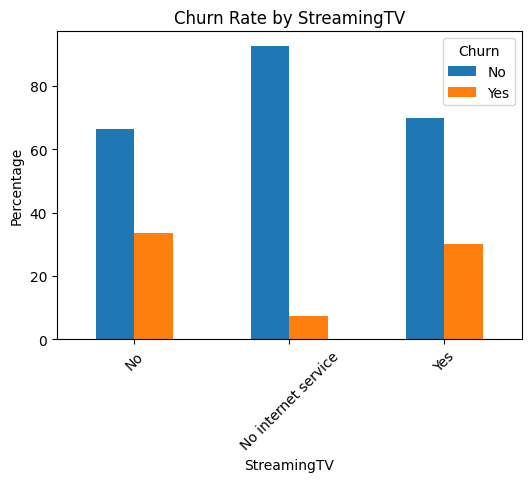

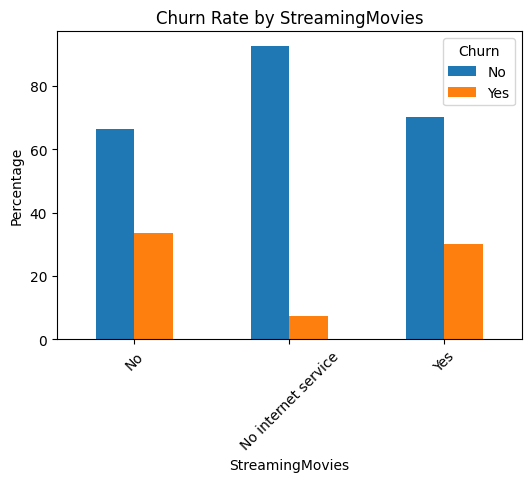

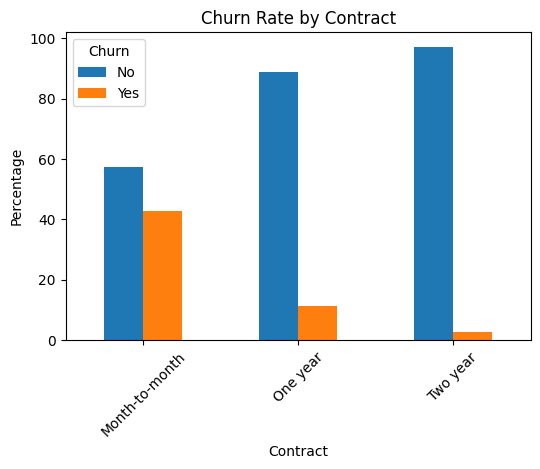

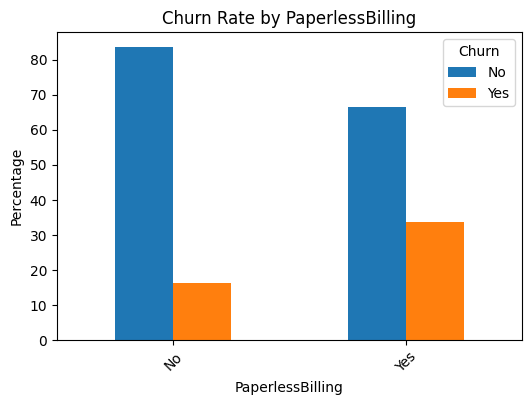

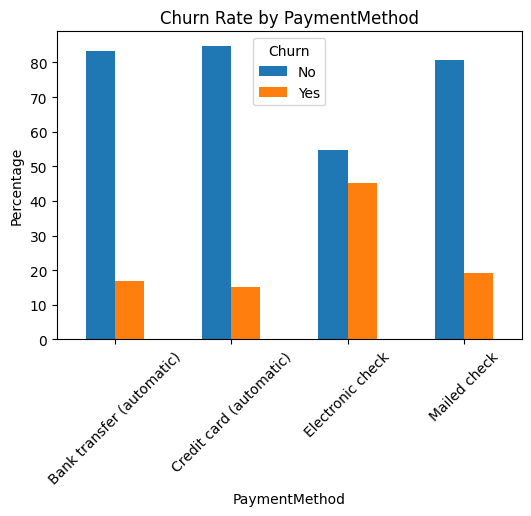

In [ ]:
import matplotlib.pyplot as plt

for feature in categorical_features:
    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100

    churn_rate.plot(kind="bar", figsize=(6,4))
    plt.title(f"Churn Rate by {feature}")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.show()

Separate Features (X) and Target (y)

In [ ]:
# Remove customerID
df.drop("customerID", axis=1, inplace=True)

# Features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

No  → 0
Yes → 1

In [ ]:
y = y.map({
    "No": 0,
    "Yes": 1
})

Encode Categorical Variables using One-Hot Encoding.

## 5. Data Preprocessing

Encode categorical variables, prepare feature matrix and target variable, and convert the dataset into a machine-learning-ready format.

In [ ]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


Split into Training and Testing Sets. 80%- Training set and 20%- Test set

## 6. Train-Test Split

Split the data into training and testing sets to evaluate model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


Feature Scaling- Logistic Regression performs better when features are on comparable scales.

## 7. Feature Scaling

Standardize numerical features to improve the performance of algorithms sensitive to feature scales.

In [ ]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(
    X_train[numeric_features]
)

X_test[numeric_features] = scaler.transform(
    X_test[numeric_features]
)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.8052594171997157
Precision: 0.6515151515151515
Recall   : 0.5748663101604278
F1 Score : 0.6107954545454546

Confusion Matrix
[[918 115]
 [159 215]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



WE GENERATED THE RESULTS FOR LOGISTIC REGRESSION CLASSIFICATION MODEL


## 8. Baseline Model Training and Comparison

Train multiple classification algorithms using the same preprocessing pipeline and compare them using Accuracy, Precision, Recall, and F1-score.

In [ ]:
#IMPORTING ALL MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

In [ ]:
#train every model automatically
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8053,0.6515,0.5749,0.6108
2,Random Forest,0.7882,0.6234,0.5134,0.5630
4,KNN,0.7605,0.5486,0.5588,0.5536
3,SVM,0.7854,0.6324,0.4599,0.5325
1,Decision Tree,0.7164,0.4661,0.4599,0.4630


NOW THE HYPERPARAMETER TUNING, RANDOM FOREST AND SVM


## 9. Hyperparameter Tuning

Optimize the Random Forest classifier using GridSearchCV with 5-fold cross-validation and F1-score as the evaluation metric.

In [ ]:
#tuning random forest
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
#using 5 fold cross validation

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


RandomForestClassifier(random_state=42)

#start training
grid_search.fit(X_train, y_train)

#now we see the best parameters
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:
print(grid_search.best_score_)

0.5799322896329068


## ***"There isn't a better Random Forest within this search space."***
Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation, optimizing the F1-score. The tuned Random Forest achieved performance comparable to the default model but did not outperform Logistic Regression on the test set. This suggests that the dataset is well-suited to a simpler linear classifier.



In [ ]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7903340440653873
Precision: 0.6321070234113713
Recall   : 0.5053475935828877
F1 Score : 0.5616641901931649


## Feature Importance

## 10. Feature Importance Analysis

Use the tuned Random Forest model to rank the importance of input features and identify the most influential predictors of customer churn.

In [ ]:
#using the Random Forest because one of its strengths is that it naturally provides feature importance scores.
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,tenure,0.182865
3,TotalCharges,0.160851
2,MonthlyCharges,0.124068
10,InternetService_Fiber optic,0.064206
25,Contract_Two year,0.059125
28,PaymentMethod_Electronic check,0.057469
13,OnlineSecurity_Yes,0.037121
24,Contract_One year,0.033782
19,TechSupport_Yes,0.027195
26,PaperlessBilling_Yes,0.021329


Then we'll select the top 10

## 10. Feature Importance Analysis

Use the tuned Random Forest model to rank the importance of input features and identify the most influential predictors of customer churn.

In [ ]:
top10_features = feature_importance.head(10)["Feature"].tolist()

print(top10_features)

['tenure', 'TotalCharges', 'MonthlyCharges', 'InternetService_Fiber optic', 'Contract_Two year', 'PaymentMethod_Electronic check', 'OnlineSecurity_Yes', 'Contract_One year', 'TechSupport_Yes', 'PaperlessBilling_Yes']


FEATURE IMPORTANCE PLOT

## 10. Feature Importance Analysis

Use the tuned Random Forest model to rank the importance of input features and identify the most influential predictors of customer churn.

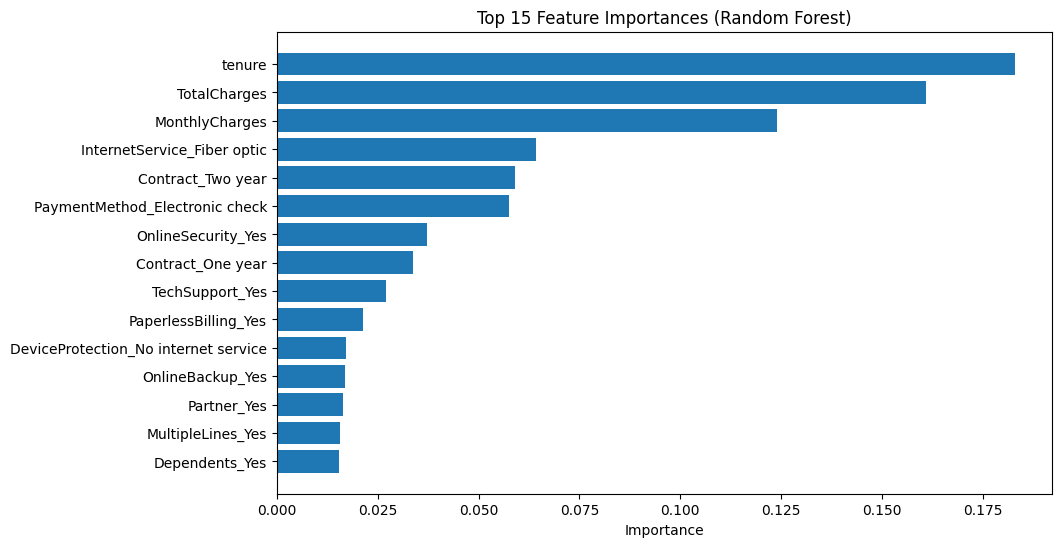

In [ ]:
import matplotlib.pyplot as plt

top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"], top15["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")

plt.show()

## 11. Feature Selection and Final Model

Select the top 10 most important features, retrain the best-performing model, and compare its performance with the model trained on all features.

In [ ]:
#new datasets
X_train_top10 = X_train[top10_features]
X_test_top10 = X_test[top10_features]

#training the logistic regression model with new data
best_model = LogisticRegression(random_state=42)
best_model.fit(X_train_top10, y_train)
y_pred = best_model.predict(X_test_top10)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7938877043354655
Precision: 0.6346153846153846
Recall   : 0.5294117647058824
F1 Score : 0.577259475218659
